# Powerlifting Total Predictor

Predict a competitive powerlifter's **competition Total (kg)** — Squat + Bench + Deadlift combined —
from nothing but their **profile**: sex, age, bodyweight, equipment category, drug-tested status,
and federation. No lift numbers are used as inputs, so this is a genuine "how much could a lifter
like this be expected to total?" prediction, not just arithmetic on Squat+Bench+Deadlift.

**Data source:** [OpenPowerlifting](https://www.openpowerlifting.org/) bulk CSV export
(`openpowerlifting-2026-08-01`), released into the public domain (CC0). The raw export has
~4.0 million entries across all lift types and federations worldwide. For this project it was
filtered down to full power meets (Squat+Bench+Deadlift, i.e. `Event == "SBD"`) with complete,
valid lift and bodyweight data, then sampled to 250,000 rows for a fast, portfolio-sized dataset
(`openpowerlifting_clean.csv`, ~29 MB).

**Project structure:**
1. Load & inspect the data
2. Exploratory data analysis
3. Feature engineering (avoiding target leakage)
4. Train/test split & preprocessing pipeline
5. Train and compare multiple regression models
6. Evaluate the best model (metrics, residuals, feature importance)
7. Save the model and demo live predictions


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import joblib

RANDOM_STATE = 42
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(RANDOM_STATE)


## 1. Load & inspect the data

In [2]:
df = pd.read_csv("openpowerlifting_clean.csv")
print("Shape:", df.shape)
df.head()


Shape: (250000, 19)


,Name,Sex,Event,Equipment,Age,Division,BodyweightKg,WeightClassKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,TotalKg,Place,Dots,Wilks,Tested,Country,Federation,Date
0,William Gladstone,M,SBD,Wraps,41.5,Open,60.00,60,136.08,88.45,199.58,424.11,5,357.97,361.71,NaN,USA,AAU,1965-09-04
1,Frank DiGiacomo,M,SBD,Wraps,26.5,Open,75.00,75,192.78,151.05,215.46,559.28,4,401.24,398.52,NaN,USA,AAU,1965-09-04
2,Terence Todd,M,SBD,Wraps,27.0,Open,151.61,90+,306.18,216.36,335.66,858.20,1,460.19,474.12,NaN,USA,AAU,1965-09-04
3,Ron Collins,M,SBD,Wraps,31.5,Open,75.00,75,217.50,150.00,235.00,602.50,1,432.25,429.32,Yes,England,BAWLA,1966-02-27
4,Jim Kenyon,M,SBD,Wraps,17.0,Open,67.50,67.5,185.97,106.59,217.72,510.29,3,393.30,393.44,NaN,USA,AAU,1966-09-03


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Name             250000 non-null  object 
 1   Sex              250000 non-null  object 
 2   Event            250000 non-null  object 
 3   Equipment        250000 non-null  object 
 4   Age              250000 non-null  float64
 5   Division         249780 non-null  object 
 6   BodyweightKg     250000 non-null  float64
 7   WeightClassKg    247437 non-null  object 
 8   Best3SquatKg     250000 non-null  float64
 9   Best3BenchKg     250000 non-null  float64
 10  Best3DeadliftKg  250000 non-null  float64
 11  TotalKg          250000 non-null  float64
 12  Place            250000 non-null  object 
 13  Dots             250000 non-null  float64
 14  Wilks            250000 non-null  float64
 15  Tested           189849 non-null  object 
 16  Country          245429 non-null  obje

In [4]:
df.isna().sum().sort_values(ascending=False)


Tested             60151
Country             4571
WeightClassKg       2563
Division             220
Name                   0
TotalKg                0
Federation             0
Wilks                  0
Dots                   0
Place                  0
Best3BenchKg           0
Best3DeadliftKg        0
Sex                    0
Best3SquatKg           0
BodyweightKg           0
Age                    0
Equipment              0
Event                  0
Date                   0
dtype: int64

`Tested` is blank whenever the meet was untested (OpenPowerlifting only fills it in as `"Yes"`
for drug-tested meets), and a handful of `Federation` / `WeightClassKg` / `Division` values are
missing. None of the columns the model will actually use (`Sex`, `Age`, `BodyweightKg`,
`Equipment`, `TotalKg`) have missing values, since those were required to be non-null during
filtering.

In [5]:
df["Tested"] = df["Tested"].fillna("No")
df["Federation"] = df["Federation"].astype(str).fillna("Unknown")
df.select_dtypes(include=[np.number]).describe()


,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,TotalKg,Dots,Wilks
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,28.748190,83.681617,180.752288,115.534343,199.529382,495.815965,364.432689,362.604196
std,11.991424,21.747082,67.004569,48.297521,60.793090,169.914821,78.648911,78.445350
min,13.000000,28.000000,12.500000,9.100000,18.100000,40.800000,41.320000,42.030000
25%,20.000000,67.250000,130.000000,75.000000,150.000000,355.000000,312.080000,310.320000
50%,25.000000,81.550000,177.500000,115.000000,200.000000,496.680000,362.910000,361.040000
75%,34.500000,97.300000,225.000000,147.500000,245.000000,615.000000,414.800000,412.680000
max,89.000000,246.800000,575.000000,442.500000,458.000000,1365.310000,818.060000,793.010000


## 2. Exploratory data analysis

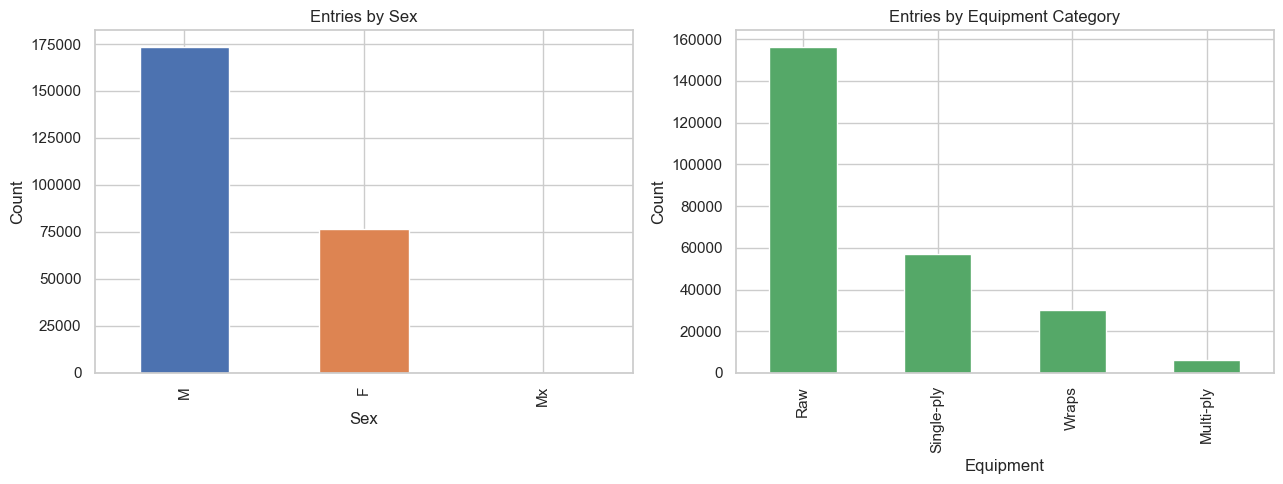

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df["Sex"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Entries by Sex")
axes[0].set_ylabel("Count")

df["Equipment"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Entries by Equipment Category")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


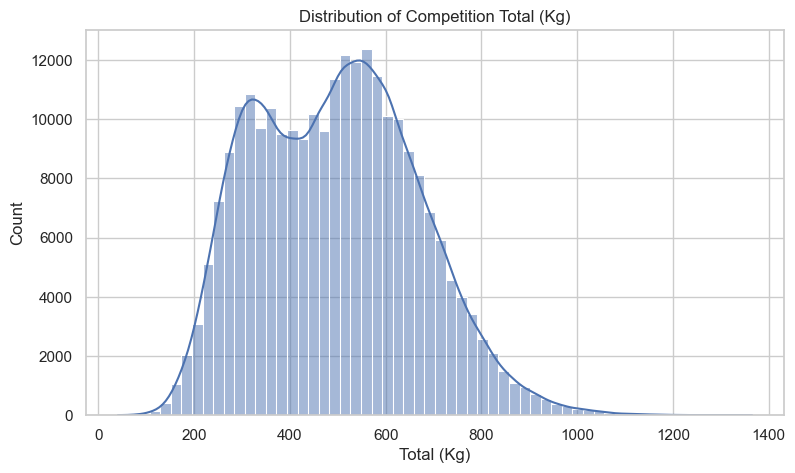

In [7]:
plt.figure(figsize=(9, 5))
sns.histplot(df["TotalKg"], bins=60, kde=True, color="#4C72B0")
plt.title("Distribution of Competition Total (Kg)")
plt.xlabel("Total (Kg)")
plt.show()


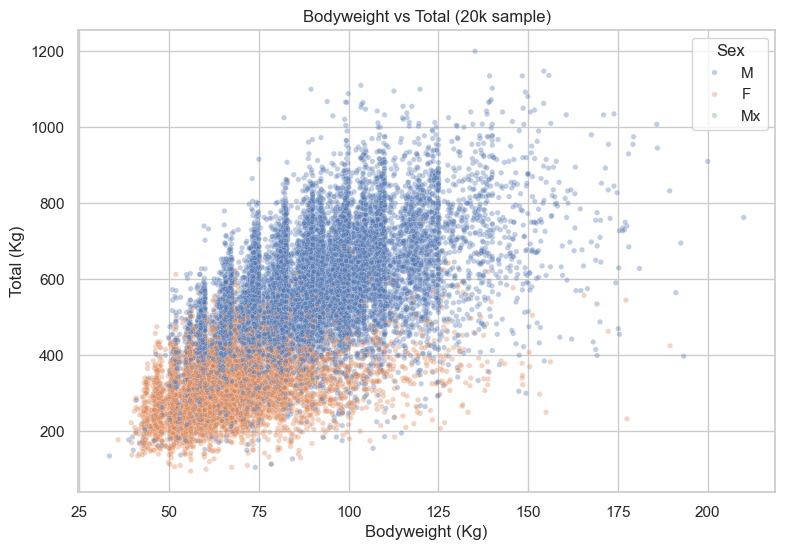

In [8]:
plt.figure(figsize=(9, 6))
sample = df.sample(20000, random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x="BodyweightKg", y="TotalKg", hue="Sex", alpha=0.35, s=15)
plt.title("Bodyweight vs Total (20k sample)")
plt.xlabel("Bodyweight (Kg)")
plt.ylabel("Total (Kg)")
plt.show()


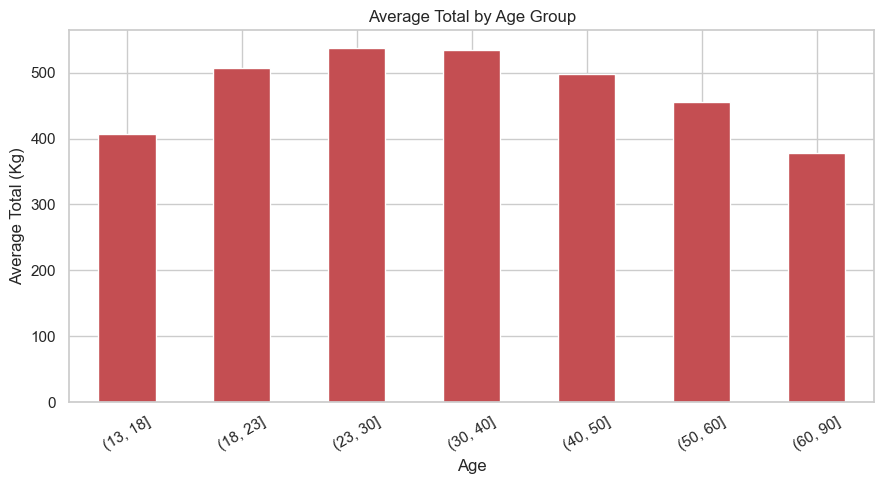

In [9]:
age_bins = pd.cut(df["Age"], bins=[13, 18, 23, 30, 40, 50, 60, 90])
age_totals = df.groupby(age_bins, observed=True)["TotalKg"].mean()

plt.figure(figsize=(9, 5))
age_totals.plot(kind="bar", color="#C44E52")
plt.title("Average Total by Age Group")
plt.ylabel("Average Total (Kg)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


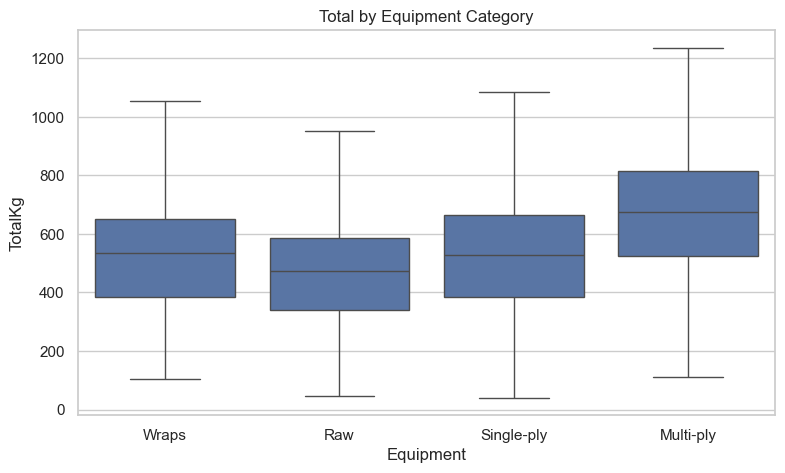

In [10]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Equipment", y="TotalKg", showfliers=False)
plt.title("Total by Equipment Category")
plt.show()


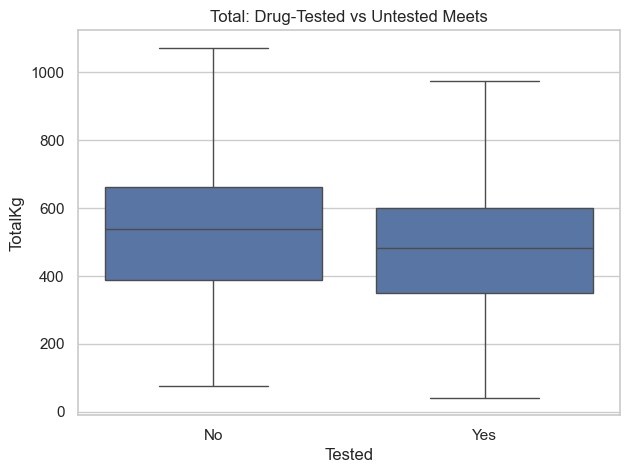

In [11]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Tested", y="TotalKg", showfliers=False)
plt.title("Total: Drug-Tested vs Untested Meets")
plt.show()


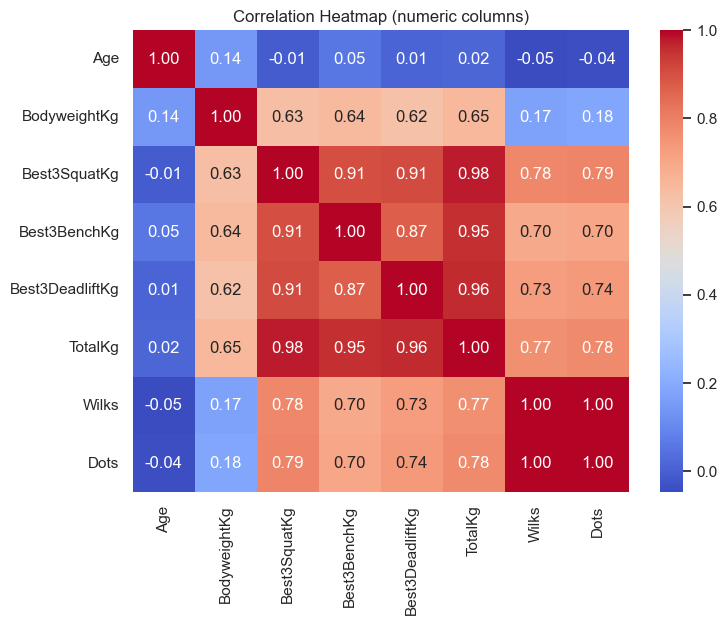

In [12]:
plt.figure(figsize=(8, 6))
corr = df[["Age", "BodyweightKg", "Best3SquatKg", "Best3BenchKg",
           "Best3DeadliftKg", "TotalKg", "Wilks", "Dots"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (numeric columns)")
plt.show()


`Best3SquatKg`, `Best3BenchKg`, `Best3DeadliftKg`, `Wilks`, and `Dots` are all extremely (or by
definition, in Wilks/Dots' case) correlated with `TotalKg` — using any of them as a **model
input** would leak the answer. The prediction model below deliberately excludes all of them and
uses only information known about a lifter *before* they compete: sex, age, bodyweight, equipment,
tested status, and federation.

## 3. Feature engineering

In [13]:
# Keep the federation feature manageable: top 15 federations by entry count, everything else -> "Other"
top_feds = df["Federation"].value_counts().nlargest(15).index
df["FederationGrouped"] = np.where(df["Federation"].isin(top_feds), df["Federation"], "Other")

feature_cols = ["Sex", "Age", "BodyweightKg", "Equipment", "Tested", "FederationGrouped"]
target_col = "TotalKg"

X = df[feature_cols].copy()
y = df[target_col].copy()

categorical_features = ["Sex", "Equipment", "Tested", "FederationGrouped"]
numeric_features = ["Age", "BodyweightKg"]

X.head()


,Sex,Age,BodyweightKg,Equipment,Tested,FederationGrouped
0,M,41.5,60.00,Wraps,No,Other
1,M,26.5,75.00,Wraps,No,Other
2,M,27.0,151.61,Wraps,No,Other
3,M,31.5,75.00,Wraps,Yes,Other
4,M,17.0,67.50,Wraps,No,Other


## 4. Train/test split & preprocessing pipeline

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (200000, 6)  Test: (50000, 6)


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)


## 5. Train & compare models

In [16]:
models = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=14, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE (kg)": mae, "RMSE (kg)": rmse, "R2": r2})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df


,Model,MAE (kg),RMSE (kg),R2
0,Hist Gradient Boosting,64.308479,83.602970,0.756867
1,Random Forest,64.620867,83.972195,0.754715
2,Ridge Regression,77.879568,100.784358,0.646665
3,Linear Regression,77.879891,100.784583,0.646664
4,Baseline (mean),140.052794,169.551728,-0.000011


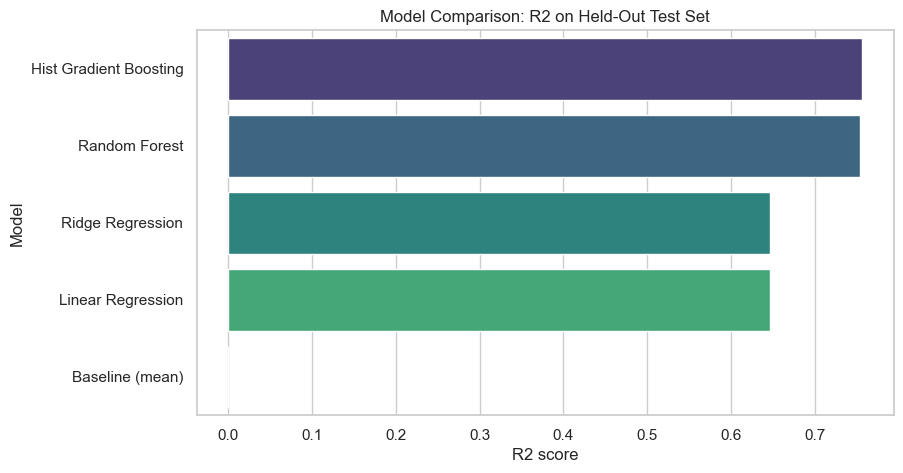

In [17]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="R2", y="Model", palette="viridis")
plt.title("Model Comparison: R2 on Held-Out Test Set")
plt.xlabel("R2 score")
plt.show()


Given that the model is only fed a lifter's **profile** (no lift numbers), an R2 well below 1.0 is
expected and honest — the biggest driver of an individual's total (training history, technique,
genetics) simply isn't captured by demographics alone. Sex, bodyweight and equipment explain a
solid chunk of the variance; the rest is inherent to the person.

In [18]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]
print("Best model:", best_model_name)


Best model: Hist Gradient Boosting


In [19]:
cv_scores = cross_val_score(best_pipeline, X, y, cv=5, scoring="r2", n_jobs=-1)
print(f"5-fold CV R2 for {best_model_name}: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print("Fold scores:", np.round(cv_scores, 3))


5-fold CV R2 for Hist Gradient Boosting: 0.746 +/- 0.020
Fold scores: [0.737 0.769 0.766 0.746 0.713]


## 6. Evaluate the best model

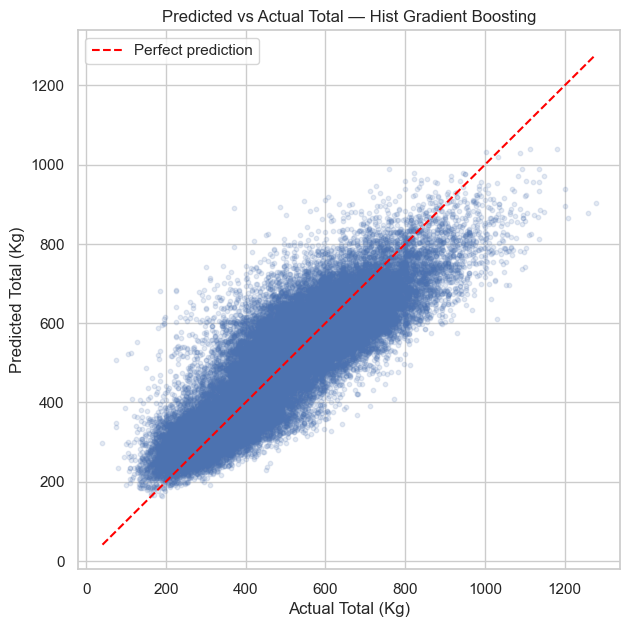

In [20]:
preds_best = best_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds_best, alpha=0.15, s=10, color="#4C72B0")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Total (Kg)")
plt.ylabel("Predicted Total (Kg)")
plt.title(f"Predicted vs Actual Total — {best_model_name}")
plt.legend()
plt.show()


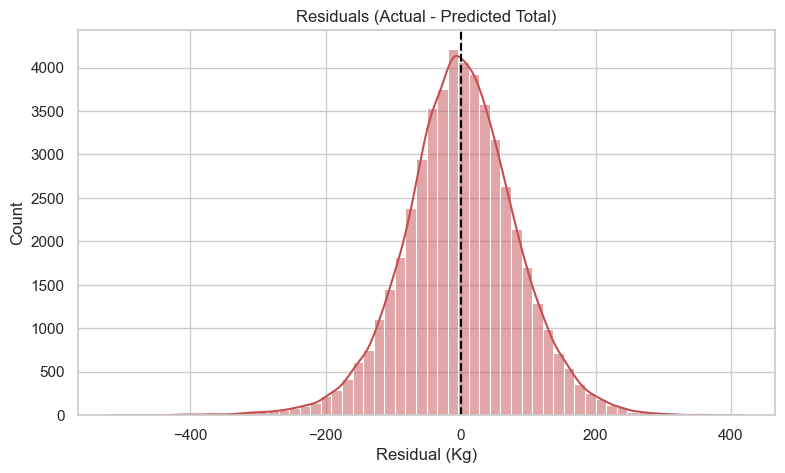

Mean residual: 0.08 kg   Std: 83.60 kg


In [21]:
residuals = y_test.values - preds_best

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=60, kde=True, color="#C44E52")
plt.axvline(0, color="black", linestyle="--")
plt.title("Residuals (Actual - Predicted Total)")
plt.xlabel("Residual (Kg)")
plt.show()

print(f"Mean residual: {residuals.mean():.2f} kg   Std: {residuals.std():.2f} kg")


In [22]:
eval_df = X_test.copy()
eval_df["Actual"] = y_test.values
eval_df["Predicted"] = preds_best
eval_df["AbsError"] = (eval_df["Actual"] - eval_df["Predicted"]).abs()

print("Mean absolute error by Sex:")
print(eval_df.groupby("Sex", observed=True)["AbsError"].mean())
print()
print("Mean absolute error by Equipment:")
print(eval_df.groupby("Equipment", observed=True)["AbsError"].mean())


Mean absolute error by Sex:
Sex
F     50.967011
M     70.143657
Mx    25.641556
Name: AbsError, dtype: float64

Mean absolute error by Equipment:
Equipment
Multi-ply     93.263658
Raw           60.195084
Single-ply    70.696616
Wraps         68.089170
Name: AbsError, dtype: float64


### Feature importance (permutation importance on the held-out test set)

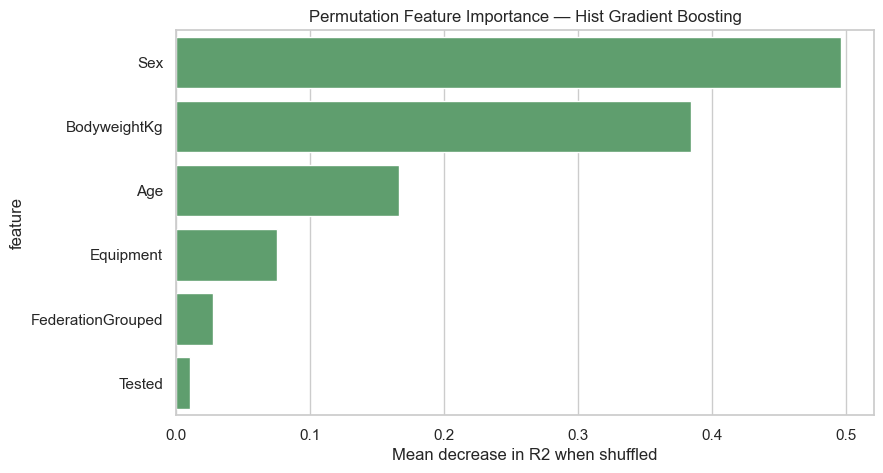

,feature,importance_mean,importance_std
0,Sex,0.496061,0.004025
2,BodyweightKg,0.384496,0.002918
1,Age,0.166554,0.001579
3,Equipment,0.074991,0.001822
5,FederationGrouped,0.027635,0.000464
4,Tested,0.010091,0.000159


In [23]:
perm = permutation_importance(
    best_pipeline, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="importance_mean", y="feature", color="#55A868")
plt.title(f"Permutation Feature Importance — {best_model_name}")
plt.xlabel("Mean decrease in R2 when shuffled")
plt.show()

importance_df


## 7. Save the model & try live predictions

In [24]:
joblib.dump(best_pipeline, "powerlifting_total_model.joblib")
print("Saved model to powerlifting_total_model.joblib")


Saved model to powerlifting_total_model.joblib


In [25]:
def predict_total(sex, age, bodyweight_kg, equipment="Raw", tested="Yes", federation="USAPL"):
    """Predict a lifter's competition Total (Kg) from their profile."""
    fed_grouped = federation if federation in top_feds else "Other"
    row = pd.DataFrame([{
        "Sex": sex,
        "Age": age,
        "BodyweightKg": bodyweight_kg,
        "Equipment": equipment,
        "Tested": tested,
        "FederationGrouped": fed_grouped,
    }])
    pred = best_pipeline.predict(row)[0]
    return round(pred, 1)


examples = [
    dict(sex="M", age=25, bodyweight_kg=83, equipment="Raw", tested="Yes", federation="USAPL"),
    dict(sex="F", age=30, bodyweight_kg=60, equipment="Raw", tested="Yes", federation="USAPL"),
    dict(sex="M", age=45, bodyweight_kg=100, equipment="Single-ply", tested="No", federation="WPC"),
    dict(sex="F", age=19, bodyweight_kg=52, equipment="Wraps", tested="No", federation="Other"),
]

for ex in examples:
    pred = predict_total(**ex)
    print(f"{ex}  ->  predicted total: {pred} kg")


{'sex': 'M', 'age': 25, 'bodyweight_kg': 83, 'equipment': 'Raw', 'tested': 'Yes', 'federation': 'USAPL'}  ->  predicted total: 577.1 kg
{'sex': 'F', 'age': 30, 'bodyweight_kg': 60, 'equipment': 'Raw', 'tested': 'Yes', 'federation': 'USAPL'}  ->  predicted total: 308.0 kg
{'sex': 'M', 'age': 45, 'bodyweight_kg': 100, 'equipment': 'Single-ply', 'tested': 'No', 'federation': 'WPC'}  ->  predicted total: 691.7 kg
{'sex': 'F', 'age': 19, 'bodyweight_kg': 52, 'equipment': 'Wraps', 'tested': 'No', 'federation': 'Other'}  ->  predicted total: 264.8 kg


In [26]:
# Sanity check against a few real, held-out lifters
sample_test = X_test.sample(5, random_state=RANDOM_STATE)
sample_actual = y_test.loc[sample_test.index]
sample_pred = best_pipeline.predict(sample_test)

comparison = sample_test.copy()
comparison["ActualTotal"] = sample_actual.values
comparison["PredictedTotal"] = np.round(sample_pred, 1)
comparison["ErrorKg"] = (comparison["ActualTotal"] - comparison["PredictedTotal"]).round(1)
comparison


,Sex,Age,BodyweightKg,Equipment,Tested,FederationGrouped,ActualTotal,PredictedTotal,ErrorKg
147033,M,33.0,111.6,Wraps,No,Other,592.5,710.0,-117.5
165939,F,72.0,79.3,Raw,No,USPA,262.5,246.1,16.4
242421,M,37.5,97.6,Raw,Yes,USAPL,697.5,578.2,119.3
103385,M,17.0,99.9,Raw,No,USPA,617.5,528.6,88.9
39830,M,22.5,98.4,Single-ply,Yes,USAPL,700.0,696.7,3.3


## Conclusions & limitations

- The best model (see the comparison table in section 5) explains a meaningful share of the
  variance in competition Total using **only pre-competition profile data** — no lift numbers.
- **Bodyweight and Sex dominate feature importance**, consistent with how powerlifting federations
  themselves normalize scores (Wilks/Dots exist precisely because bodyweight and sex have such a
  large effect on raw totals).
- **Equipment** (Raw vs Single-ply vs Multi-ply) and **Tested status** shift totals substantially —
  supportive/multi-ply gear and untested meets are associated with higher totals, as expected.
- The remaining, unexplained variance is the interesting part: two lifters with an identical
  profile can have very different totals depending on training age, technique, and genetics —
  none of which is in this dataset. A production version of this project could improve accuracy by
  adding lifter history (prior meet totals, years training) as features, at the cost of no longer
  being a "cold start" predictor.
